In [7]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from typing import Tuple
from sklearn.model_selection import train_test_split

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## Ключевые функции

Функции оценки модели:

In [8]:
def nasa_scoring_function(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Вычисляет метрику NASA Scoring Function."""
    errors = y_pred - y_true
    scores = np.zeros_like(errors, dtype=float)
    
    late_mask = errors < 0
    scores[late_mask] = np.exp(-errors[late_mask] / 13) - 1
    
    early_mask = errors >= 0
    scores[early_mask] = np.exp(errors[early_mask] / 10) - 1
    
    return np.mean(scores)

def evaluate_model(y_true: np.ndarray, y_pred: np.ndarray) -> Tuple[float, ...]:
    """Вычисляет все метрики для оценки модели."""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    nasa_score = nasa_scoring_function(y_true, y_pred)
    
    metrics = {
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2,
        'NASA_Score': nasa_score
    }
    
    return metrics

def print_metrics(metrics, model_name="Model"):
    """Печатает метрики в красивом формате."""
    print(f"{model_name}")
    print("-" * 40)
    for metric, value in metrics.items():
        print(f"  {metric}: {value:.4f}")
    print("-" * 40)

Загрузка данных:

In [9]:
def load_sequences(dataset_name: str, data_dir: str = '../data/processed'):
    """Загружает последовательности для глубокого обучения."""
    data_path = Path(data_dir) / dataset_name / 'sequences'
    
    X_train = np.load(data_path / 'X_train_seq.npy')
    y_train = np.load(data_path / 'y_train_seq.npy')
    X_test = np.load(data_path / 'X_test_seq.npy')
    y_path = Path(data_dir) / dataset_name / 'y_test.csv'
    if y_path.exists():
        y_test = pd.read_csv(y_path).to_numpy(dtype='float32').reshape(-1)
    else:
        y_test = None
        print(f"y_test не найден для {dataset_name}")
    
    print(f"{dataset_name}")
    print(f"  X_train: {X_train.shape}")
    print(f"  y_train: {y_train.shape}")
    print(f"  X_test:  {X_test.shape}")
    if y_test is not None:
        print(f"  y_test:  {y_test.shape}")
    
    return X_train, y_train, X_test, y_test

In [116]:
# test
X_train, y_train, X_test, y_test = load_sequences('FD002')

FD002
  X_train: (46219, 30, 24)
  y_train: (46219,)
  X_test:  (259, 30, 24)
  y_test:  (259,)


np.array -> dataloaders:

In [117]:
def create_dataloaders(X_train, y_train, X_test, y_test=None, 
                       batch_size=32, val_split=0.2):
    """Создает DataLoader."""
    # Разбиение на train/val
    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, 
        test_size=val_split, 
        random_state=0
    )
    
    # Преобразование в тензоры
    X_train_t = torch.FloatTensor(X_train)
    y_train_t = torch.FloatTensor(y_train).view(-1, 1)
    X_val_t = torch.FloatTensor(X_val)
    y_val_t = torch.FloatTensor(y_val).view(-1, 1)
    X_test_t = torch.FloatTensor(X_test)
    
    # DataLoader
    train_dataset = TensorDataset(X_train_t, y_train_t)
    val_dataset = TensorDataset(X_val_t, y_val_t)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    
    if y_test is not None:
        y_test_t = torch.FloatTensor(y_test).view(-1, 1)
        test_dataset = TensorDataset(X_test_t, y_test_t)
        test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    else:
        test_loader = DataLoader(TensorDataset(X_test_t), batch_size=batch_size, shuffle=False)
    
    print(f"Datasets:")
    print(f"  Train: {len(train_dataset)} samples")
    print(f"  Val:   {len(val_dataset)} samples")
    print(f"  Test:  {len(X_test)} samples")
    
    return train_loader, val_loader, test_loader

In [118]:
train_loader, val_loader, test_loader = create_dataloaders(X_train, y_train, X_test, y_test)

Datasets:
  Train: 36975 samples
  Val:   9244 samples
  Test:  259 samples


Функции обучения:

In [119]:
def train_epoch(model, train_loader, criterion, optimizer, device):
    """Обучает модель на одной эпохе."""
    model.train()
    total_loss = 0
    predictions = []
    targets = []
    
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        
        optimizer.zero_grad()
        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * X_batch.size(0)
        predictions.extend(y_pred.cpu().detach().numpy().flatten())
        targets.extend(y_batch.cpu().detach().numpy().flatten())
    
    avg_loss = total_loss / len(train_loader.dataset)
    return avg_loss, np.array(predictions), np.array(targets)

In [120]:
def evaluate(model, val_loader, criterion, device):
    """Оценивает модель на валидационных данных."""
    model.eval()
    total_loss = 0
    predictions = []
    targets = []
    
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            
            total_loss += loss.item() * X_batch.size(0)
            predictions.extend(y_pred.cpu().detach().numpy().flatten())
            targets.extend(y_batch.cpu().detach().numpy().flatten())
    
    avg_loss = total_loss / len(val_loader.dataset)
    return avg_loss, np.array(predictions), np.array(targets)

In [133]:
def train_model(model, train_loader, val_loader, epochs=100, lr=1e-3, patience=10, device=device):
    """Полный цикл обучения модели с early stopping."""
    model = model.to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
    
    history = {
        'train_loss': [],
        'val_loss': [],
        'lr': []
    }
    
    best_val_loss = float('inf')
    patience_counter = 0
    best_model_state = None
    
    print(f"{'Epoch':>8} | {'Train Loss':>12} | {'Val Loss':>10} | {'LR':>10}")
    print("-" * 55)
    
    for epoch in range(epochs):
        train_loss, _, _ = train_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, _, _ = evaluate(model, val_loader, criterion, device)
        
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['lr'].append(optimizer.param_groups[0]['lr'])
        
        scheduler.step(val_loss)
        
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"{epoch+1:>8} | {train_loss:>12.4f} | {val_loss:>10.4f} | "
                  f"{optimizer.param_groups[0]['lr']:>10.2e}")
        
        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            best_model_state = model.state_dict().copy()
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping на эпохе {epoch+1}")
                break
    
    # Загружаем лучшую модель
    model.load_state_dict(best_model_state)
    
    return model, history

Оценка моделей:

In [20]:
def evaluate_on_test(model, test_loader, device, model_name):
    """Оценивает модель на тестовых данных."""
    model.eval()
    predictions = []
    targets = []
    
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            
            y_pred = model(X_batch)
            
            predictions.extend(y_pred.cpu().detach().numpy().flatten())
            targets.extend(y_batch.cpu().detach().numpy().flatten())

    y_pred = np.array(predictions)
    y_test = np.array(targets)
    
    metrics = evaluate_model(y_test, y_pred)
    print_metrics(metrics, model_name)
    return metrics, y_pred

## 1D-CNN

In [134]:
class CNN1D(nn.Module):
    def __init__(self, input_size, window_size, num_filters=64, kernel_size=3):
        super(CNN1D, self).__init__()
        
        self.conv1_1 = nn.Conv1d(input_size, num_filters, kernel_size, padding='same')
        self.bn1_1 = nn.BatchNorm1d(num_filters)
        self.conv1_2 = nn.Conv1d(num_filters, num_filters, kernel_size, padding='same')
        self.bn1_2 = nn.BatchNorm1d(num_filters)
        self.pool1 = nn.MaxPool1d(2)
        
        self.conv2_1 = nn.Conv1d(num_filters, num_filters*2, kernel_size, padding='same')
        self.bn2_1 = nn.BatchNorm1d(num_filters*2)
        self.conv2_2 = nn.Conv1d(num_filters*2, num_filters*2, kernel_size, padding='same')
        self.bn2_2 = nn.BatchNorm1d(num_filters*2)
        self.pool2 = nn.MaxPool1d(2)
        
        self.conv3_1 = nn.Conv1d(num_filters*2, num_filters*4, kernel_size, padding='same')
        self.bn3_1 = nn.BatchNorm1d(num_filters*4)
        self.conv3_2 = nn.Conv1d(num_filters*4, num_filters*4, kernel_size, padding='same')
        self.bn3_2 = nn.BatchNorm1d(num_filters*4)
        self.pool3 = nn.MaxPool1d(2)
        
        self.gap = nn.AdaptiveAvgPool1d(1)
        self.fc1 = nn.Linear(num_filters*4, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 1)
        
        self.relu = nn.ReLU()
        
    def forward(self, x):
        # x: (batch_size, window_size, input_size), нужно поменять местами каналы (input_size) и последовательности (window_size)
        x = x.permute(0, 2, 1)
        
        x = self.relu(self.bn1_1(self.conv1_1(x)))
        x = self.relu(self.bn1_2(self.conv1_2(x)))
        x = self.pool1(x)
        
        x = self.relu(self.bn2_1(self.conv2_1(x)))
        x = self.relu(self.bn2_2(self.conv2_2(x)))
        x = self.pool2(x)
        
        x = self.relu(self.bn3_1(self.conv3_1(x)))
        x = self.relu(self.bn3_2(self.conv3_2(x)))
        x = self.pool3(x)
        
        x = self.gap(x)
        x = x.view(x.size(0), -1)
        
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        
        return x

Тестирование:

In [135]:
input_size = X_train.shape[2]
window_size = X_train.shape[1]
model_cnn = CNN1D(input_size, window_size)
model_cnn, history_cnn = train_model(model_cnn, train_loader, val_loader)

   Epoch |   Train Loss |   Val Loss |         LR
-------------------------------------------------------
       1 |     742.5167 |   400.0041 |   1.00e-03
      10 |      64.4821 |    48.3052 |   1.00e-03
      20 |      31.1409 |    26.2977 |   1.00e-03
      30 |      19.0946 |    25.1086 |   1.00e-03
      40 |      14.7996 |    23.3405 |   5.00e-04
      50 |       5.8239 |     9.9018 |   5.00e-04
      60 |       3.4444 |     5.9736 |   2.50e-04
      70 |       2.9794 |     6.9108 |   1.25e-04
      80 |       1.8424 |     3.7186 |   6.25e-05
      90 |       1.6745 |     3.7764 |   6.25e-05
Early stopping на эпохе 97


<Axes: >

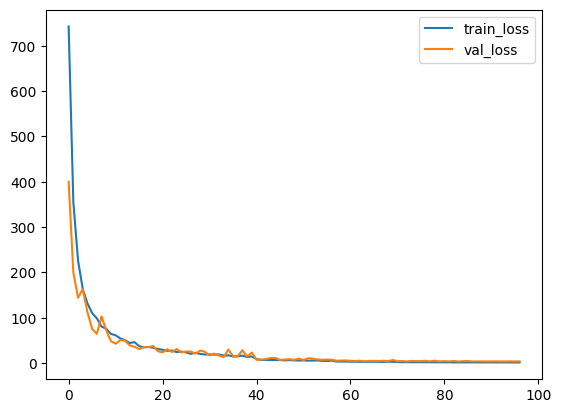

In [138]:
history_df = pd.DataFrame(history_cnn)
history_df.loc[:, ['train_loss', 'val_loss']].plot()

In [139]:
test_metrics_cnn, y_pred_cnn = evaluate_on_test(model_cnn, test_loader, device, '1D-CNN')

1D-CNN
----------------------------------------
  MAE: 16.3246
  RMSE: 21.9903
  R2: 0.7530
  NASA_Score: 32.9320
----------------------------------------


## LSTM

In [122]:
class LSTMModel(nn.Module):
    """
    LSTM модель для прогнозирования RUL.
    """
    def __init__(self, input_size, hidden_size=128, num_layers=2, dropout=0.3):
        super(LSTMModel, self).__init__()
        
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=True
        )

        
        self.fc1 = nn.Linear(hidden_size* 2, 64)
        self.fc2 = nn.Linear(64, 1)
        
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x):
        # x: (batch_size, window_size, input_size)
        lstm_out, _ = self.lstm(x)
        last_output = lstm_out[:, -1, :]
        
        x = self.relu(self.fc1(last_output))
        x = self.dropout(x)
        x = self.fc2(x)
        
        return x

In [128]:
input_size = X_train.shape[2]
window_size = X_train.shape[1]
model_lstm = LSTMModel(input_size, hidden_size=128, num_layers=2)
model_lstm, history_lstm = train_model(model_lstm, train_loader, val_loader, epochs=100)

   Epoch |   Train Loss |   Val Loss |         LR
-------------------------------------------------------
       1 |    1882.6909 |   741.0581 |   1.00e-03
      10 |     176.7286 |    75.8348 |   1.00e-03
      20 |     105.1318 |    28.2138 |   1.00e-03
      30 |      87.5165 |    17.4514 |   1.00e-03
      40 |      78.9361 |    20.5526 |   1.00e-03
      50 |      68.9639 |    11.3734 |   1.00e-03
      60 |      57.7702 |     5.0582 |   5.00e-04
      70 |      50.9762 |     3.0938 |   2.50e-04
      80 |      49.5841 |     2.6147 |   1.25e-04
      90 |      48.6609 |     1.7231 |   6.25e-05
     100 |      47.7525 |     2.0930 |   3.13e-05
Early stopping на эпохе 100


<Axes: >

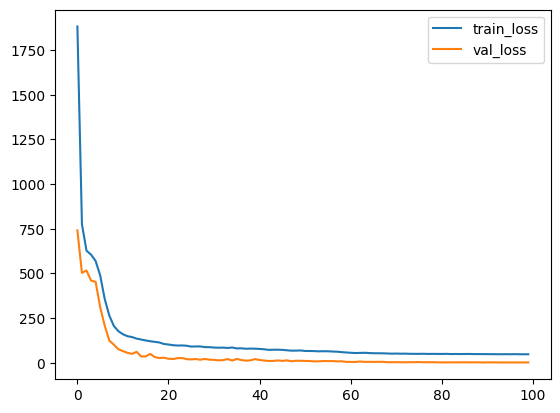

In [131]:
history_df = pd.DataFrame(history_lstm)
history_df.loc[:, ['train_loss', 'val_loss']].plot()

In [132]:
test_metrics_lstm, y_pred_lstm = evaluate_on_test(model_lstm, test_loader, device, 'LSTM')

LSTM
----------------------------------------
  MAE: 15.5348
  RMSE: 22.0084
  R2: 0.7526
  NASA_Score: 163.8907
----------------------------------------
